# Minimization

Minimization seeks the parameter values that minimize an objective function. Unlike root finding, which determines the solution satisfying $f(x)=0$, minimization searches for the parameters that produce the smallest value of a prescribed cost or loss function. In computational physics, minimization is widely used for parameter estimation, optimal control, inverse problems, machine learning, and energy minimization. This notebook demonstrates parameter optimization by tuning a PID controller for one-dimensional trajectory tracking.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from matplotlib.animation import FuncAnimation

plt.rcParams.update({ "font.family": "Times New Roman", "mathtext.fontset": "cm", "font.size": 14 })

## Reference Trajectory

The desired robot motion is described using a critically damped trajectory,

$$
x_d(t)=x_f+\left[C_1+C_2t\right]e^{-\omega t},
$$

where

$$
C_1=x_0-x_f,
$$

$$
C_2=\omega(x_0-x_f),
$$

$x_0$ and $x_f$ denote the initial and target positions, respectively, while $\omega$ controls the convergence speed. This trajectory provides a smooth reference without oscillatory behavior.

In [2]:
def critical_damped(t, x0, xf, omega=5):
    C1 = x0 - xf
    C2 = omega * (x0 - xf)
    return xf + (C1 + C2*t) * np.exp(-omega*t)

## PID Controller

The robot is controlled using a proportional-integral-derivative (PID) controller,

$$
u(t)=K_Pe(t)+K_I\int e(t)\,dt+K_D\frac{de(t)}{dt},
$$

where

$$
e(t)=x_d(t)-x(t)
$$

is the tracking error between the reference trajectory and the robot position. The proportional, integral, and derivative gains determine the controller response and are treated as optimization variables.

In [3]:
class PID:
    def __init__(self, kp, ki, kd):
        self.kp = kp
        self.ki = ki
        self.kd = kd
        self.reset()

    def reset(self):
        self.integral = 0
        self.prev_error = 0

    def control(self, error, dt):
        self.integral += error * dt
        derivative = (error - self.prev_error) / dt
        self.prev_error = error
        return self.kp * error + self.ki * self.integral + self.kd * derivative

## Objective Function


The objective is to determine the parameter vector

$$
\boldsymbol{\theta}
=
\begin{bmatrix}
K_P\\
K_I\\
K_D
\end{bmatrix},
$$

by minimizing the loss function

$$
L(\boldsymbol{\theta})=\mathrm{RMSE}+2O,
$$

where

$$
\mathrm{RMSE}=\sqrt{\frac{1}{n}\sum_{i=1}^{n}\left(x_i-x_{d,i}\right)^2},
$$

measures the trajectory tracking error, and

$$
O=
\begin{cases}
\max\left(0,\max(x)-x_f\right), & x_f>x_0,\\
\max\left(0,x_f-\min(x)\right), & x_f<x_0,
\end{cases}
$$

represents the overshoot beyond the desired target position. The overshoot term is multiplied by two to penalize excessive oscillations more strongly than the tracking error alone.

Since the robot trajectory depends nonlinearly on the controller gains, the optimal parameters cannot generally be obtained analytically. Instead, iterative optimization algorithms are employed to minimize the objective function. The following code estimates the optimal PID gains using `scipy.optimize.minimize`.

In [4]:
def simulate_1d(pid, x0, xf, v_max=2, a_max=5, T=3, dt=0.01):
    n = int(T/dt)
    x, v = x0, 0
    ts, xs = [], []
    pid.reset()
    for i in range(n):
        t = i * dt
        target = critical_damped(t, x0, xf)
        error = target - x
        u = np.clip(pid.control(error, dt), -a_max, a_max)
        x += v * dt
        v += u * dt
        v = np.clip(v, -v_max, v_max)
        ts.append(t)
        xs.append(x)
    return np.array(ts), np.array(xs)

In [5]:
def loss(params, x0, xf):
    kp, ki, kd = params
    ts, xs = simulate_1d(PID(kp, ki, kd), x0, xf)
    target = critical_damped(ts, x0, xf)
    rmse = np.sqrt(np.mean((xs - target)**2))
    overshoot = max(0, np.max(xs - xf)) if xf > x0 else max(0, np.max(xf - xs))
    return rmse + 2 * overshoot

## Optimal PID Parameters

The optimization procedure determines the values of $K_P$, $K_I$, and $K_D$ that minimize the loss function while satisfying the prescribed parameter bounds.

In [6]:
x0, xf = 0, 1
result = minimize(loss, x0=[25, 25, 25], args=(x0, xf), bounds=[(0, 50), (0, 50), (0, 50)])
kp_opt, ki_opt, kd_opt = result.x
print("Optimal:", kp_opt, ki_opt, kd_opt)

Optimal: 50.0 0.0 19.065348444878133


In [7]:
pid_opt = PID(kp_opt, ki_opt, kd_opt)
ts, xs = simulate_1d(pid_opt, x0, xf)
target = critical_damped(ts, x0, xf)

## Trajectory Tracking

The optimized PID controller is evaluated by comparing the simulated robot trajectory with the desired critically damped reference trajectory.

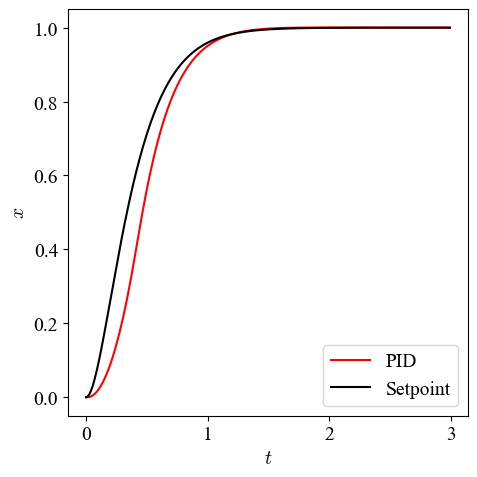

In [8]:
plt.figure(figsize=(5, 5))
plt.plot(ts, xs, color="r", label="PID")
plt.plot(ts, target, color="k", label="Setpoint")
plt.xlabel(r"$t$")
plt.ylabel(r"$x$")
plt.legend()
plt.tight_layout()
plt.show()

## Animation

The animation illustrates the motion of the robot and the moving reference target throughout the trajectory. It provides a visual assessment of the tracking performance achieved by the optimized controller.

MovieWriter ffmpeg unavailable; using Pillow instead.


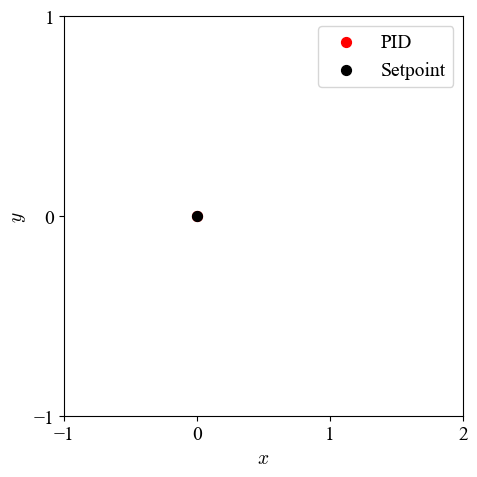

In [9]:
fig, ax = plt.subplots(figsize=(5, 5))
point_pid = ax.scatter([], [], c="r", label="PID", s=50)
point_target = ax.scatter([], [], c="k", label="Setpoint", s=50)
ax.set_xlim(-1, 2)
ax.set_xlabel(r"$x$")
ax.set_xticks([-1, 0, 1, 2])
ax.set_ylim(-1, 1)
ax.set_ylabel(r"$y$")
ax.set_yticks([-1, 0, 1])
ax.legend()

def update(frame):
    point_pid.set_offsets([[xs[frame], 0]])
    point_target.set_offsets([[target[frame], 0]])
    return point_pid, point_target

plt.tight_layout()
ani = FuncAnimation(fig, update, frames=len(xs), interval=20)
ani.save("minimization.gif")

## Key Insights

* Minimization determines the parameter values that minimize an objective function.
* PID tuning can be formulated as an optimization problem by treating the controller gains as decision variables.
* The loss function combines trajectory tracking accuracy and overshoot into a single optimization criterion.
* Iterative optimization algorithms automatically search for the controller gains that produce the best tracking performance.